In [16]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from cns.process.breakpoints import make_breaks
from cns.data_utils import load_COSMIC
import random
import numpy as np

cosmic_genes = load_COSMIC()
cosmic_genes.head()

_, start, end = make_breaks("arms")["chr3"]
gene_start, gene_end = cosmic_genes.query("gene == 'SOX2'")[["start", "end"]].values.tolist()[0]

In [18]:
# Initialize a list to store the ranges
ranges = []

reps = 50

# seed random to 0
random.seed(0)

# Repeat until 8 ranges are sampled
while len(ranges) < 5 * reps:
    # Generate a random range
    if random.random() < 0.66:
        rand_start = random.randint(start, end)
    else:
        rand_start = start
    if random.random() < 0.5:
        rand_end = random.randint(rand_start, end)
    else:
        rand_end = end

    # Check if the range contains gene_start and gene_end
    if rand_start <= gene_start and rand_end >= gene_end:
        # If it does, add it to the list
        ranges.append((rand_start, rand_end))

In [19]:
breaks = np.array(ranges).flatten()
breaks.sort()
split_ranges = []

for r_start, r_end in ranges:
    current_start = r_start

    for brk in breaks:
        if r_start < brk < r_end:
            split_ranges.append((current_start, brk))
            current_start = brk

    split_ranges.append((current_start, r_end))

In [20]:
import pandas as pd

# Count the occurrences of each pair
counts = pd.Series(split_ranges).value_counts().reset_index()

# Rename the columns
counts.columns = ['range', 'CN']

# Split the range into start and end
counts[['start', 'end']] = pd.DataFrame(counts['range'].tolist(), index=counts.index)

# Drop the 'range' column
counts = counts.drop('range', axis=1)

# Reorder the columns
counts = counts[['start', 'end', 'CN']].sort_values(by=['start'], ignore_index=True)
counts["CN"] = counts["CN"] / reps + 2
counts.head()

,start,end,CN
0,91000000,91009282,3.82
1,91009282,91455375,3.84
2,91455375,91603068,3.86
3,91603068,91964296,3.88
4,91964296,92976931,3.90


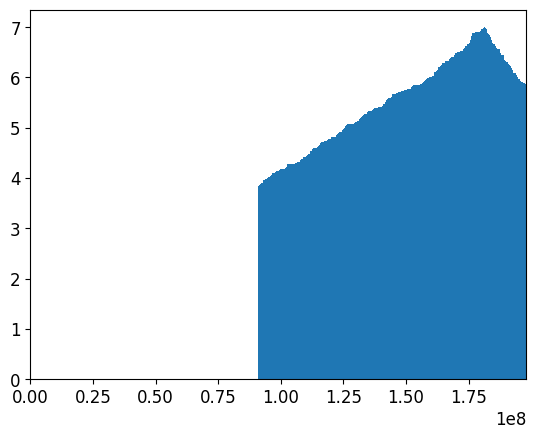

In [21]:
import matplotlib.pyplot as plt

# Calculate the widths of the bars
widths = counts['end'] - counts['start']

# Create a bar plot
plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))

# Display the plot
plt.show()

In [22]:
from cns.data_utils import load_merged_samples, load_merged_cns, get_cns_for_type

samples = load_merged_samples().query("type == 'LUSC'")
cns = load_merged_cns(samples)
data_chrom3 = cns.query("chrom == 'chr3'")

In [23]:
from cns.process.breakpoints import get_breaks
data_breaks = get_breaks(data_chrom3)

In [24]:
from cns.process.binning import bin_by_breaks

binned_data = bin_by_breaks(data_chrom3, data_breaks, print_progress=True)

Binned into 4574794 CNS.                                        


In [25]:
from cns.process.binning import group_bins, add_cns_loc

groups = group_bins(add_cns_loc(binned_data))

In [26]:
groups

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,492498232,chr3,0,96476,48238,96476,1.858268,0.125984,1.984252
1,492611887,chr3,96476,227311,161893,130835,1.860517,0.125984,1.986502
2,492708893,chr3,227311,290487,258899,63176,1.861642,0.125984,1.987627
3,492742812,chr3,290487,295149,292818,4662,1.862767,0.125984,1.988751
4,492790654,chr3,295149,386172,340660,91023,1.865017,0.125984,1.991001
...,...,...,...,...,...,...,...,...,...
5141,690045566,chr3,197580979,197610165,197595572,29186,4.391451,1.629921,6.021372
5142,690130421,chr3,197610165,197750689,197680427,140524,4.392576,1.629921,6.022497
5143,690215284,chr3,197750689,197779891,197765290,29202,4.391451,1.629921,6.021372
5144,690250180,chr3,197779891,197820482,197800186,40591,4.390326,1.629921,6.020247


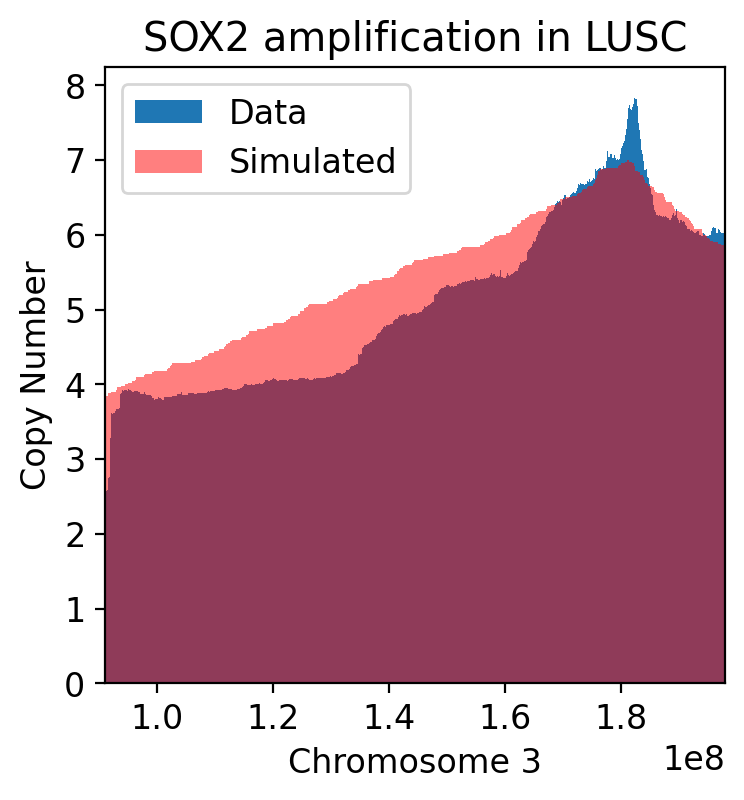

In [27]:
# bar plot groups 
fig, ax = plt.subplots(figsize=(4, 4), dpi=200)

# double font size
plt.rcParams.update({'font.size': 12})

# Create a bar plot
plt.bar(x=groups['start'], height=groups['total_cn'], width=(groups['end'] - groups['start']), align='edge')

plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge', alpha=0.5, color='red')


# Set the x-axis start to 0
plt.xlim(start, max(counts['end']))

# label
plt.xlabel("Chromosome 3")
plt.ylabel("Copy Number")
plt.title("SOX2 amplification in LUSC")

# add legend
plt.legend(["Data", "Simulated"])
